# Armado de dataset para entrenar

In [112]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from itertools import product

In [114]:
df_2023 = pd.read_csv('../data/processed/recorridos/trips_2023.csv')
df_2024 = pd.read_csv('../data/processed/recorridos/trips_2024.csv')
dataset = pd.concat([df_2023, df_2024], ignore_index=True)
dataset["fecha_destino_recorrido"] = pd.to_datetime(dataset["fecha_destino_recorrido"])
print(f"Shape combinado: {dataset.shape}")
dataset = dataset[dataset['duracion_recorrido'] <= 7200]
dataset = dataset.dropna()
dataset.to_csv('../data_new/dataset.csv', index=False)

Shape combinado: (4777976, 17)


In [115]:
df = pd.read_csv('../data_new/dataset.csv', parse_dates=["fecha_destino_recorrido"])
print(f"Shape: {df.shape}")

Shape: (4724761, 17)


In [116]:
df_ordenado = df.sort_values(by="fecha_destino_recorrido")
df_ordenado["ventana"] = df_ordenado["fecha_destino_recorrido"].dt.floor("30min")
df_ordenado.to_csv("../data_new/ddataset_ordenado.csv", index=False, date_format="%Y-%m-%d %H:%M:%S")

In [117]:
print(f"Shape ordenado: {df_ordenado.shape}")

Shape ordenado: (4724761, 18)


Hasta ahora lo unico que hicimos es:
- juntar el datset 2023 + 2024
- eliminar los viajes que teneian nans, y los recorridos que eran demasiado largos (outliers)
- ordenar el dataset en orden ascendente por fecha de estacion destino

## Comienzo analisis extra
A partir de aca hago analisis que no es encesario replciarlos en un set de testeo

In [118]:
# Estoy haciendo un conteo de las estaciones de destino, la cantidad de arribos en total que tuvo cada estacion, y defino las coordenadas de cada una
conteo_estaciones = df_ordenado["id_estacion_destino"].value_counts().rename("cantidad_de_arribos").reset_index()
conteo_estaciones = conteo_estaciones.rename(columns={"index": "id_estacion_destino"})
coordenadas_estaciones = df_ordenado[["id_estacion_destino", "long_estacion_destino", "lat_estacion_destino"]].drop_duplicates()
tabla_estaciones = pd.merge(conteo_estaciones, coordenadas_estaciones, on="id_estacion_destino")
print(tabla_estaciones)

     id_estacion_destino  cantidad_de_arribos  long_estacion_destino  \
0                  175.0                53613             -58.380707   
1                   14.0                53471             -58.426387   
2                    8.0                45892             -58.389336   
3                    5.0                44917             -58.420954   
4                  202.0                41672             -58.390602   
..                   ...                  ...                    ...   
566                553.0                   13             -58.500942   
567                313.0                   12             -58.444954   
568                550.0                   10             -58.527098   
569                233.0                    8             -58.436037   
570                402.0                    2             -58.498542   

     lat_estacion_destino  
0              -34.626851  
1              -34.577424  
2              -34.609422  
3              -34.5805

In [119]:
tabla = tabla_estaciones[["cantidad_de_arribos", "id_estacion_destino"]].copy()
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(tabla)

centroides = kmeans.cluster_centers_
orden = np.argsort(centroides[:, 0])

cluster_to_label = {
    orden[0]: "fantasma",
    orden[1]: "normal",
    orden[2]: "central",
    orden[3]: "super_central"
}
tabla_estaciones["tipo_estacion"] = [cluster_to_label[c] for c in labels]

In [120]:
print(tabla_estaciones)

     id_estacion_destino  cantidad_de_arribos  long_estacion_destino  \
0                  175.0                53613             -58.380707   
1                   14.0                53471             -58.426387   
2                    8.0                45892             -58.389336   
3                    5.0                44917             -58.420954   
4                  202.0                41672             -58.390602   
..                   ...                  ...                    ...   
566                553.0                   13             -58.500942   
567                313.0                   12             -58.444954   
568                550.0                   10             -58.527098   
569                233.0                    8             -58.436037   
570                402.0                    2             -58.498542   

     lat_estacion_destino  tipo_estacion  
0              -34.626851  super_central  
1              -34.577424  super_central  
2     

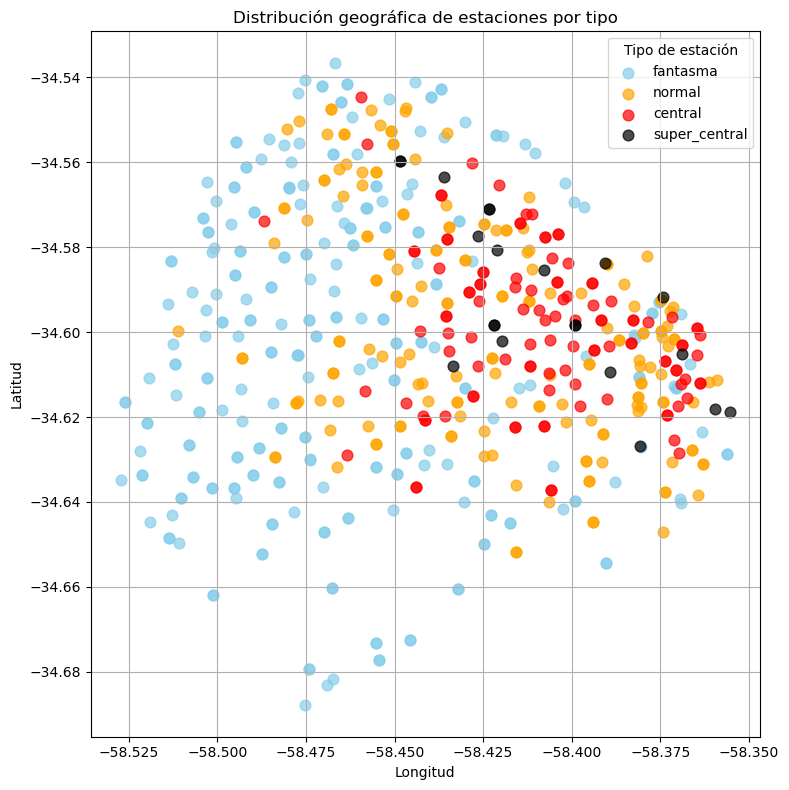

In [121]:
colores = {
    "fantasma": "skyblue",
    "normal": "orange",
    "central": "red",
    "super_central": "black"
}

plt.figure(figsize=(8, 8))

for tipo, color in colores.items():
    subset = tabla_estaciones[tabla_estaciones["tipo_estacion"] == tipo]
    plt.scatter(
        subset["long_estacion_destino"],
        subset["lat_estacion_destino"],
        label=tipo,
        color=color,
        alpha=0.7,
        s=60
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Distribución geográfica de estaciones por tipo")
plt.legend(title="Tipo de estación")
plt.grid(True)
plt.tight_layout()
plt.show()


In [122]:
tipo_estacion_dicc = dict(zip(tabla_estaciones["id_estacion_destino"], tabla_estaciones["tipo_estacion"]))

## Finalizo analisis extra

Vuevlo al desarrollo para todos los x

In [123]:
data = pd.read_csv("../data_new/ddataset_ordenado.csv")

In [124]:
df_model = (
    data.groupby(["ventana", "id_estacion_destino"])
    .size()
    .reset_index(name="cantidad_arribos")
)
print(df_model[:10])

               ventana  id_estacion_destino  cantidad_arribos
0  2023-01-01 00:00:00                 23.0                 1
1  2023-01-01 00:00:00                 41.0                 1
2  2023-01-01 00:00:00                118.0                 1
3  2023-01-01 00:00:00                131.0                 1
4  2023-01-01 00:00:00                363.0                 1
5  2023-01-01 00:00:00                449.0                 2
6  2023-01-01 00:30:00                  3.0                 1
7  2023-01-01 00:30:00                 33.0                 1
8  2023-01-01 00:30:00                 45.0                 1
9  2023-01-01 00:30:00                 56.0                 2


In [125]:
df_model["ventana"] = pd.to_datetime(df_model["ventana"])
df_model["estacion"] = df_model["ventana"].apply(obtener_season)
df_model["es_finde"] = df_model["ventana"].dt.weekday >= 5

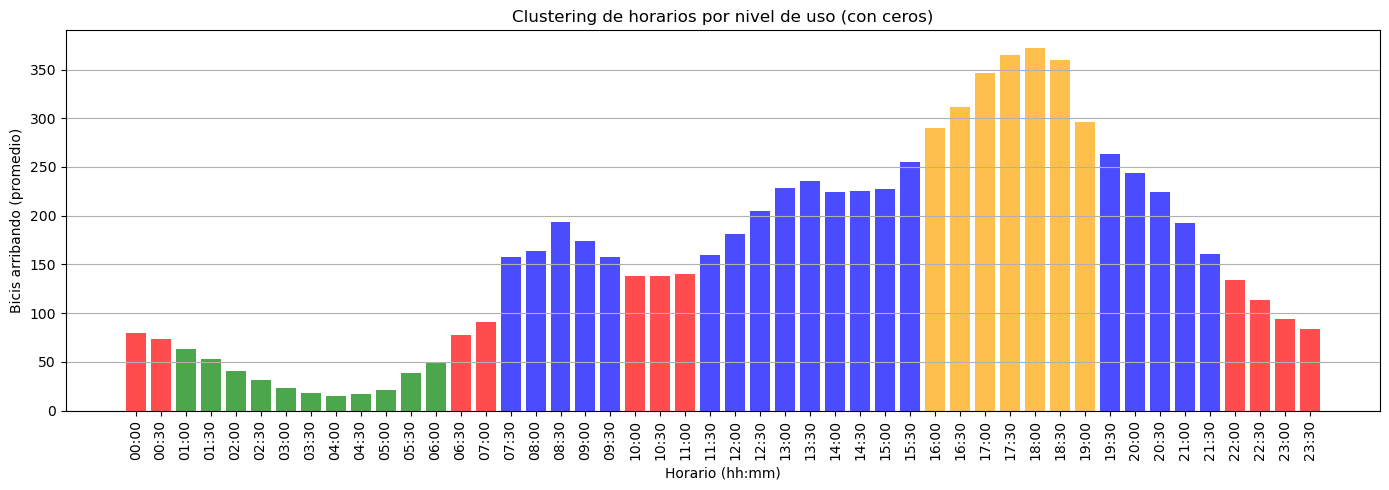

In [126]:
fechas = df_model["ventana"].dt.date
horas = df_model["ventana"].dt.strftime("%H:%M")
arribos = df_model["cantidad_arribos"]

df_aux = pd.DataFrame({
    "fecha": fechas,
    "hora_30min": horas,
    "arribos": arribos
})

agrupado = df_aux.groupby(["fecha", "hora_30min"])["arribos"].sum().reset_index()
fechas_unicas = agrupado["fecha"].unique()
horas_unicas = agrupado["hora_30min"].unique()
combinaciones = pd.DataFrame(product(fechas_unicas, horas_unicas), columns=["fecha", "hora_30min"])
df_completo = combinaciones.merge(agrupado, on=["fecha", "hora_30min"], how="left")
df_completo["arribos"] = df_completo["arribos"].fillna(0)
promedios = df_completo.groupby("hora_30min")["arribos"].mean().reset_index(name="arribos_promedio")
X = promedios[["arribos_promedio"]]
kmeans = KMeans(n_clusters=4, random_state=42)
promedios["cluster"] = kmeans.fit_predict(X)
promedios["minuto_del_dia"] = promedios["hora_30min"].apply(lambda x: int(x[:2]) * 60 + int(x[3:]))
promedios = promedios.sort_values("minuto_del_dia")

colores = {0: "blue", 1: "red", 2: "green", 3: "orange"}
plt.figure(figsize=(14, 5))
for _, row in promedios.iterrows():
    plt.bar(row["hora_30min"], row["arribos_promedio"], color=colores[row["cluster"]], alpha=0.7)

plt.xticks(rotation=90)
plt.xlabel("Horario (hh:mm)")
plt.ylabel("Bicis arribando (promedio)")
plt.title("Clustering de horarios por nivel de uso (con ceros)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [127]:
centroides = kmeans.cluster_centers_.flatten()
orden = np.argsort(centroides)
cluster_to_label = {
    orden[0]: "bajo",
    orden[1]: "moderado",
    orden[2]: "activo",
    orden[3]: "pico"
}

horario_a_cluster = {
    row["hora_30min"]: cluster_to_label[row["cluster"]]
    for _, row in promedios.iterrows()
}
print(horario_a_cluster)

{'00:00': 'moderado', '00:30': 'moderado', '01:00': 'bajo', '01:30': 'bajo', '02:00': 'bajo', '02:30': 'bajo', '03:00': 'bajo', '03:30': 'bajo', '04:00': 'bajo', '04:30': 'bajo', '05:00': 'bajo', '05:30': 'bajo', '06:00': 'bajo', '06:30': 'moderado', '07:00': 'moderado', '07:30': 'activo', '08:00': 'activo', '08:30': 'activo', '09:00': 'activo', '09:30': 'activo', '10:00': 'moderado', '10:30': 'moderado', '11:00': 'moderado', '11:30': 'activo', '12:00': 'activo', '12:30': 'activo', '13:00': 'activo', '13:30': 'activo', '14:00': 'activo', '14:30': 'activo', '15:00': 'activo', '15:30': 'activo', '16:00': 'pico', '16:30': 'pico', '17:00': 'pico', '17:30': 'pico', '18:00': 'pico', '18:30': 'pico', '19:00': 'pico', '19:30': 'activo', '20:00': 'activo', '20:30': 'activo', '21:00': 'activo', '21:30': 'activo', '22:00': 'moderado', '22:30': 'moderado', '23:00': 'moderado', '23:30': 'moderado'}


IMPORTANTE: 'horario_a_cluster' es un diccionario donde se decreta que dada una hora, te dice el tipo de horario

In [128]:
df_model["horario"] = df_model["ventana"].apply(clasificar_horario)
df_model["tipo_estacion"] = df_model["id_estacion_destino"].map(tipo_estacion_dicc)
print(df_model.shape)

(2736982, 7)


In [129]:
lat_dict = dict(zip(tabla_estaciones["id_estacion_destino"], tabla_estaciones["lat_estacion_destino"]))
long_dict = dict(zip(tabla_estaciones["id_estacion_destino"], tabla_estaciones["long_estacion_destino"]))

df_model["lat_estacion_destino"] = df_model["id_estacion_destino"].map(lat_dict)
df_model["long_estacion_destino"] = df_model["id_estacion_destino"].map(long_dict)

In [130]:
df_model.to_csv('../data_new/dataset_model.csv', index=False)

## Aca va todo lo que se va a ir a utils.py

In [131]:
def obtener_season(fecha):
    año = fecha.year
    # Definimos los rangos para cada estación
    if pd.Timestamp(f"{año}-12-21") <= fecha or fecha < pd.Timestamp(f"{año}-03-21"):
        return "verano"
    elif pd.Timestamp(f"{año}-03-21") <= fecha < pd.Timestamp(f"{año}-06-21"):
        return "otoño"
    elif pd.Timestamp(f"{año}-06-21") <= fecha < pd.Timestamp(f"{año}-09-21"):
        return "invierno"
    else:
        return "primavera"

In [132]:
def clasificar_horario(ventana_datetime):
    hhmm = ventana_datetime.strftime("%H:%M")
    return horario_a_cluster.get(hhmm, "desconocido") 